In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.6 MB/s eta 0:00:00


# Step 1 — Import libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from gensim.models import Word2Vec

# Step 2 — Load data

In [3]:
# Load dataset
df = pd.read_csv("books_with_clusters.csv")

# Keep only rows with valid text and labels
df = df.dropna(subset=["text_clean", "keyword_category"]).copy()

# Convert to string just in case
df["text_clean"] = df["text_clean"].astype(str)
df["keyword_category"] = df["keyword_category"].astype(str)

print("Dataset shape:", df.shape)
print(df[["Title", "text_clean", "keyword_category"]].head())
print("\nCategory distribution:")
print(df["keyword_category"].value_counts())

Dataset shape: (1985, 8)
                                               Title  \
0            The Hunger Games (The Hunger Games, #1)   
1  Harry Potter and the Sorcerer's Stone (Harry P...   
2                            Twilight (Twilight, #1)   
3                              To Kill a Mockingbird   
4                                   The Great Gatsby   

                                          text_clean keyword_category  
0  winning mean fame fortune losing mean certain ...         military  
1  harry potter life miserable parent dead stuck ...           travel  
2  three thing absolutely positive first edward v...         romantic  
3  unforgettable novel childhood sleepy southern ...          fiction  
4  alternate cover edition isbn 0743273567 isbn13...          fiction  

Category distribution:
keyword_category
other         539
fiction       401
history       287
military      243
travel        206
romantic      135
medical        52
business       42
scientific     35
psy

# Step 3 — Train/test split

In [4]:
X_text = df["text_clean"]
y = df["keyword_category"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 1588
Test size: 397


# Step 4 — Build BoW features

In [5]:
bow_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)

print("BoW train shape:", X_train_bow.shape)
print("BoW test shape:", X_test_bow.shape)

BoW train shape: (1588, 5000)
BoW test shape: (397, 5000)


# Step 5 — Build TF-IDF features

In [6]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (1588, 5000)
TF-IDF test shape: (397, 5000)


# Step 6 — Build LDA features

In [7]:
n_topics = 10

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

X_train_lda = lda_model.fit_transform(X_train_bow)
X_test_lda = lda_model.transform(X_test_bow)

print("LDA train shape:", X_train_lda.shape)
print("LDA test shape:", X_test_lda.shape)

LDA train shape: (1588, 10)
LDA test shape: (397, 10)


# Step 7 — Build Word Embedding features

In [8]:
# Tokenize text
train_tokens = [text.split() for text in X_train_text]
test_tokens = [text.split() for text in X_test_text]

# Train Word2Vec on training corpus only
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

embedding_dim = w2v_model.vector_size

def document_vector(tokens, model, dim):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

X_train_embed = np.array([document_vector(tokens, w2v_model, embedding_dim) for tokens in train_tokens])
X_test_embed = np.array([document_vector(tokens, w2v_model, embedding_dim) for tokens in test_tokens])

print("Word Embedding train shape:", X_train_embed.shape)
print("Word Embedding test shape:", X_test_embed.shape)

Word Embedding train shape: (1588, 100)
Word Embedding test shape: (397, 100)


# Step 8 — Store all feature sets

In [9]:
feature_sets = {
    "BoW": (X_train_bow, X_test_bow),
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
    "LDA": (X_train_lda, X_test_lda),
    "WordEmbedding": (X_train_embed, X_test_embed)
}

for name, (Xtr, Xte) in feature_sets.items():
    print(name, "->", Xtr.shape, Xte.shape)

BoW -> (1588, 5000) (397, 5000)
TF-IDF -> (1588, 5000) (397, 5000)
LDA -> (1588, 10) (397, 10)
WordEmbedding -> (1588, 100) (397, 100)


# Step 9 — Define models

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM": LinearSVC(random_state=42)
}

# Step 10 — Run models

In [11]:
results = []
all_predictions = {}

for feature_name, (Xtr, Xte) in feature_sets.items():
    print(f"\n========== Feature: {feature_name} ==========")

    for model_name, model in models.items():
        print(f"Training {model_name} on {feature_name}...")

        model.fit(Xtr, y_train)
        y_pred = model.predict(Xte)

        acc = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="weighted", zero_division=0
        )

        results.append({
            "Feature": feature_name,
            "Model": model_name,
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1
        })

        all_predictions[(feature_name, model_name)] = {
            "model": model,
            "y_pred": y_pred
        }

        print(f"Accuracy: {acc:.4f}, F1-score: {f1:.4f}")


========== Feature: BoW ==========
Training Logistic Regression on BoW...
Accuracy: 0.5844, F1-score: 0.5493
Training Random Forest on BoW...
Accuracy: 0.7456, F1-score: 0.7203
Training SVM on BoW...
Accuracy: 0.5894, F1-score: 0.5771

========== Feature: TF-IDF ==========
Training Logistic Regression on TF-IDF...
Accuracy: 0.4811, F1-score: 0.3875
Training Random Forest on TF-IDF...
Accuracy: 0.7179, F1-score: 0.6880
Training SVM on TF-IDF...
Accuracy: 0.5542, F1-score: 0.5251

========== Feature: LDA ==========
Training Logistic Regression on LDA...
Accuracy: 0.3350, F1-score: 0.2145
Training Random Forest on LDA...
Accuracy: 0.3678, F1-score: 0.3052
Training SVM on LDA...
Accuracy: 0.3375, F1-score: 0.2168

========== Feature: WordEmbedding ==========
Training Logistic Regression on WordEmbedding...
Accuracy: 0.2720, F1-score: 0.1164
Training Random Forest on WordEmbedding...
Accuracy: 0.2997, F1-score: 0.2322
Training SVM on WordEmbedding...
Accuracy: 0.2846, F1-score: 0.1554


# Step 11 - Summary table

In [12]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["F1-score", "Accuracy"], ascending=False).reset_index(drop=True)

results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}"
})

,Feature,Model,Accuracy,Precision,Recall,F1-score
0,BoW,Random Forest,0.7456,0.7467,0.7456,0.7203
1,TF-IDF,Random Forest,0.7179,0.7295,0.7179,0.6880
2,BoW,SVM,0.5894,0.5964,0.5894,0.5771
3,BoW,Logistic Regression,0.5844,0.5505,0.5844,0.5493
4,TF-IDF,SVM,0.5542,0.5307,0.5542,0.5251
5,TF-IDF,Logistic Regression,0.4811,0.4460,0.4811,0.3875
6,LDA,Random Forest,0.3678,0.2866,0.3678,0.3052
7,WordEmbedding,Random Forest,0.2997,0.2102,0.2997,0.2322
8,LDA,SVM,0.3375,0.1647,0.3375,0.2168
9,LDA,Logistic Regression,0.3350,0.1658,0.3350,0.2145


# Step 12 — Compare results visually

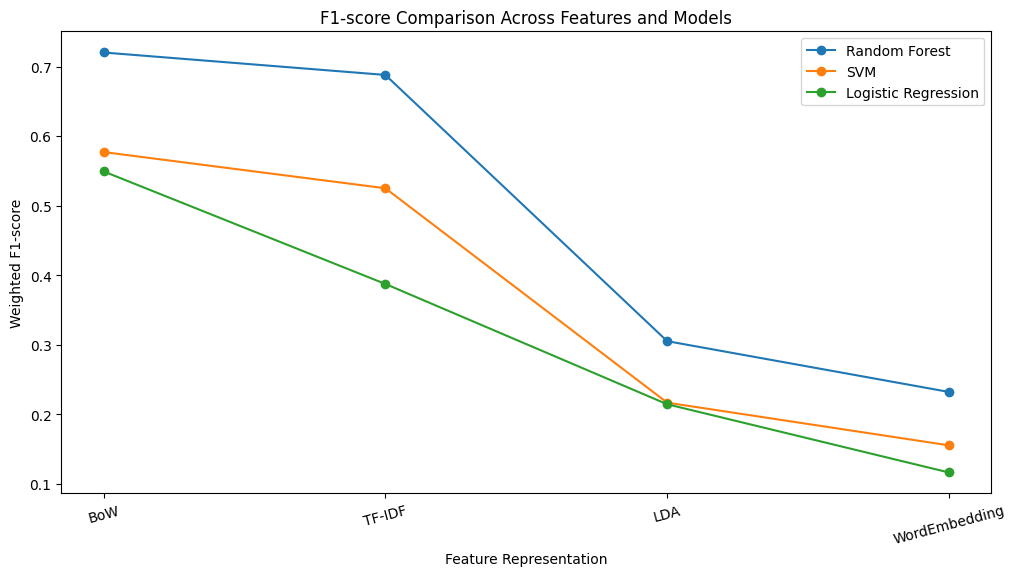

In [13]:
plt.figure(figsize=(12, 6))

for model_name in results_df["Model"].unique():
    subset = results_df[results_df["Model"] == model_name]
    plt.plot(subset["Feature"], subset["F1-score"], marker="o", label=model_name)

plt.title("F1-score Comparison Across Features and Models")
plt.xlabel("Feature Representation")
plt.ylabel("Weighted F1-score")
plt.legend()
plt.xticks(rotation=15)
plt.show()

# Step 13 — Find the best two model-feature combinations

In [14]:
best_row = results_df.iloc[0]
best_feature = best_row["Feature"]
best_model_name = best_row["Model"]

print("Feature:", best_feature)
print("Model:", best_model_name)
print(best_row)

Feature: BoW
Model: Random Forest
Feature                BoW
Model        Random Forest
Accuracy          0.745592
Precision         0.746732
Recall            0.745592
F1-score          0.720286
Name: 0, dtype: object


In [15]:
second_best_row = results_df.iloc[1]
second_best_feature = second_best_row["Feature"]
second_best_model_name = second_best_row["Model"]

print("Feature:", second_best_feature)
print("Model:", second_best_model_name)
print(second_best_row)

Feature: TF-IDF
Model: Random Forest
Feature             TF-IDF
Model        Random Forest
Accuracy          0.717884
Precision         0.729488
Recall            0.717884
F1-score          0.688023
Name: 1, dtype: object


# Step 14 — Classification report for the best two combinations

In [16]:
best_pred = all_predictions[(best_feature, best_model_name)]["y_pred"]

print(f"Best combination: {best_model_name} + {best_feature}\n")
print(classification_report(y_test, best_pred, zero_division=0))

Best combination: Random Forest + BoW

              precision    recall  f1-score   support

   biography       0.00      0.00      0.00         2
    business       0.57      0.50      0.53         8
     fiction       0.76      0.94      0.84        80
     history       1.00      0.66      0.79        58
     medical       1.00      0.20      0.33        10
    military       0.71      0.59      0.64        49
       other       0.66      0.98      0.79       108
  psychology       0.00      0.00      0.00         7
    romantic       1.00      0.74      0.85        27
  scientific       0.00      0.00      0.00         7
      travel       0.73      0.54      0.62        41

    accuracy                           0.75       397
   macro avg       0.58      0.47      0.49       397
weighted avg       0.75      0.75      0.72       397



In [17]:
second_best_pred = all_predictions[(second_best_feature, second_best_model_name)]["y_pred"]

print(f"Combination: {second_best_model_name} + {second_best_feature}\n")
print(classification_report(y_test, second_best_pred, zero_division=0))

Combination: Random Forest + TF-IDF

              precision    recall  f1-score   support

   biography       0.00      0.00      0.00         2
    business       0.60      0.38      0.46         8
     fiction       0.79      0.93      0.85        80
     history       0.97      0.64      0.77        58
     medical       1.00      0.10      0.18        10
    military       0.65      0.45      0.53        49
       other       0.61      1.00      0.76       108
  psychology       0.00      0.00      0.00         7
    romantic       1.00      0.59      0.74        27
  scientific       0.00      0.00      0.00         7
      travel       0.75      0.59      0.66        41

    accuracy                           0.72       397
   macro avg       0.58      0.42      0.45       397
weighted avg       0.73      0.72      0.69       397



# Step 15 — Confusion matrix for the best two combinations

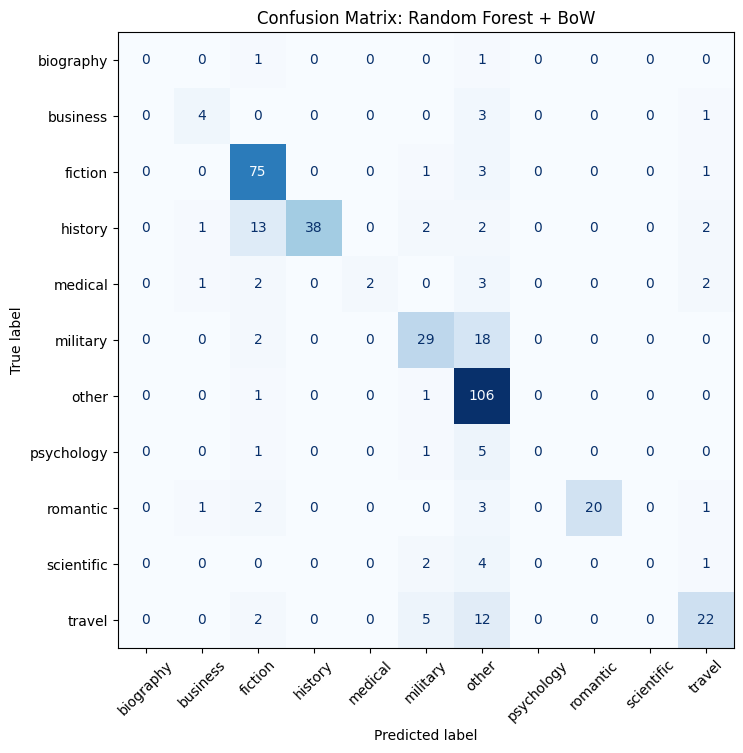

In [18]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, best_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix: {best_model_name} + {best_feature}")
plt.show()


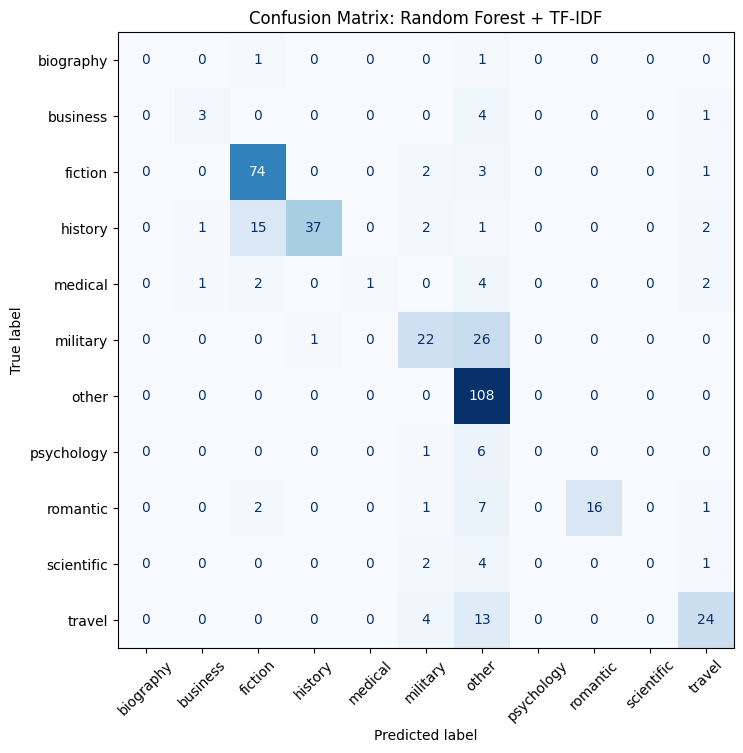

In [19]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, second_best_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix: {second_best_model_name} + {second_best_feature}")
plt.show()

# Step 16 - Error Analysis

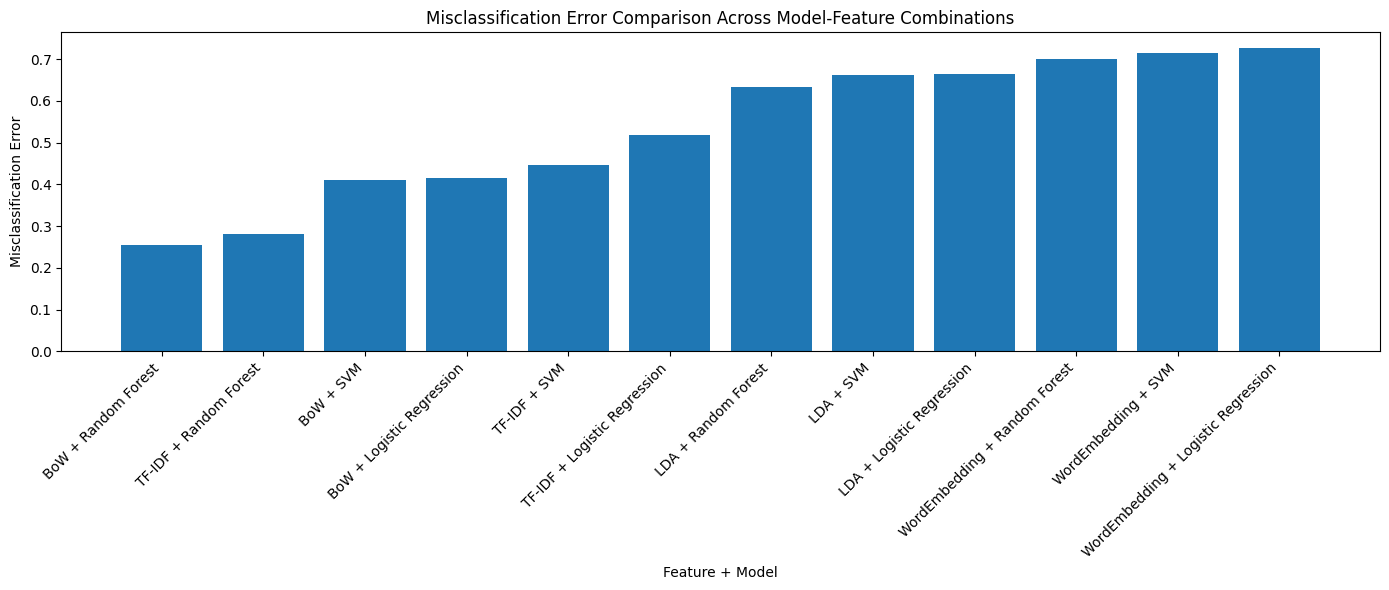

In [20]:
# Copy results
error_df = results_df.copy()

# Calculate misclassification error
error_df["Misclassification Error"] = 1 - error_df["Accuracy"]

# Create a combined label
error_df["Feature_Model"] = error_df["Feature"] + " + " + error_df["Model"]

# Sort by error (optional)
error_df = error_df.sort_values(by="Misclassification Error", ascending=True)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(error_df["Feature_Model"], error_df["Misclassification Error"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Misclassification Error")
plt.xlabel("Feature + Model")
plt.title("Misclassification Error Comparison Across Model-Feature Combinations")
plt.tight_layout()
plt.show()

**for the best two combination**

In [21]:
def get_top_misclassified_full(feature, model_name, df_test, top_n=5):

    y_pred = all_predictions[(feature, model_name)]["y_pred"]

    temp_df = df_test.copy()
    temp_df["true_label"] = y_test.values
    temp_df["predicted_label"] = y_pred

    errors_df = temp_df[
        temp_df["true_label"] != temp_df["predicted_label"]
    ].copy()

    errors_df["text_length"] = errors_df["text_clean"].apply(len)
    errors_df = errors_df.sort_values(by="text_length", ascending=False)

    return errors_df.head(top_n)

In [22]:
df_test_full = df.loc[X_test_text.index].copy()

top1_errors = get_top_misclassified_full(best_row["Feature"], best_row["Model"], df_test_full)
top2_errors = get_top_misclassified_full(second_best_row["Feature"], second_best_row["Model"], df_test_full)

print("Top 5 misclassified samples for Random Forest+BoW:")
print(top1_errors[["Title", "true_label", "predicted_label", "Description"]])
print("\nTop 5 misclassified samples for Random Forest+TF-IDF:")
print(top2_errors[["Title", "true_label", "predicted_label", "Description"]])

Top 5 misclassified samples for Random Forest+BoW:
                                                  Title true_label  \
738    The Little House Collection (Little House, #1-9)   military   
335                1st to Die (Women's Murder Club, #1)    history   
655                                     The White Tiger    history   
91    Freakonomics: A Rogue Economist Explores the H...   business   
1219                    Hard Eight (Stephanie Plum, #8)   military   

     predicted_label                                        Description  
738          fiction  This nine-book paperback box set of the classi...  
335          fiction  James Patterson, bestselling author of the Ale...  
655          fiction  Introducing a major literary talent, The White...  
91             other  Which is more dangerous, a gun or a swimming p...  
1219           other  Fugitive Apprehension Agent Stephanie Plum has...  

Top 5 misclassified samples for Random Forest+TF-IDF:
                             